<a href="https://colab.research.google.com/github/radheshyam1111/CN5006/blob/main/dissertation4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [5]:
data = pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv',index_col =[0])

In [6]:
data.head(2)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses


In [7]:
data.shape


(23486, 10)

Checking For Missing Values and Handling it

In [8]:
data.isnull().sum()/len(data)*100


,0
Clothing ID,0.000000
Age,0.000000
Title,16.222430
Review Text,3.597888
Rating,0.000000
Recommended IND,0.000000
Positive Feedback Count,0.000000
Division Name,0.059610
Department Name,0.059610
Class Name,0.059610


In [9]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


In [10]:
data.drop(labels =['Clothing ID','Title'],axis = 1,inplace = True) #Dropping unwanted columns


In [11]:
data[data['Review Text'].isnull()]


,Age,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
92,23,NaN,5,1,0,General Petite,Tops,Knits
93,31,NaN,5,1,0,General,Dresses,Dresses
98,50,NaN,5,1,0,General,Jackets,Outerwear
135,35,NaN,4,1,0,General Petite,Tops,Knits
142,35,NaN,5,1,0,General,Jackets,Outerwear
...,...,...,...,...,...,...,...,...
23258,35,NaN,4,1,0,General,Tops,Knits
23301,52,NaN,5,1,0,General,Tops,Knits
23303,46,NaN,5,1,0,General,Tops,Blouses
23470,39,NaN,5,1,0,General Petite,Dresses,Dresses


In [12]:
data = data[~data['Review Text'].isnull()]  #Dropping columns which don't have any review


In [13]:
data.shape


(22641, 8)

Data Analysis and Visualization

In [14]:
import plotly.express as px


In [15]:
px.histogram(data, x = 'Age')


In [16]:
px.histogram(data, x = data['Rating'])


In [17]:
px.histogram(data, x = data['Class Name'])


In [18]:
px.scatter(data, x="Age", y="Positive Feedback Count", facet_row="Recommended IND", facet_col="Rating",trendline="ols",category_orders={"Rating": [1,2,3,4,5],'Recommended IND':[0,1]})


In [19]:
px.violin(data, x="Age", y="Department Name", orientation="h", color="Recommended IND")


In [20]:
px.box(data, x="Age", y="Division Name", orientation="h",color = 'Recommended IND')


Cleaning the Text Data

In [21]:
err1 = data['Review Text'].str.extractall("(&amp)")
err2 = data['Review Text'].str.extractall("(\xa0)")

In [22]:
print('with &amp',len(err1[~err1.isna()]))
print('with (\xa0)',len(err2[~err2.isna()]))

with &amp 37
with ( ) 6


In [23]:
data['Review Text'] = data['Review Text'].str.replace('(&amp)','')
data['Review Text'] = data['Review Text'].str.replace('(\xa0)','')

/tmp/ipykernel_2004/1207455569.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_2004/1207455569.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [24]:
err1 = data['Review Text'].str.extractall("(&amp)")
print('with &amp',len(err1[~err1.isna()]))
err2 = data['Review Text'].str.extractall("(\xa0)")
print('with (\xa0)',len(err2[~err2.isna()]))

with &amp 37
with ( ) 6


In [25]:
!pip install TextBlob
from textblob import *

In [26]:
data['polarity'] = data['Review Text'].map(lambda text: TextBlob(text).sentiment.polarity)


/tmp/ipykernel_2004/206707623.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [27]:
data['polarity']


,polarity
0,0.633333
1,0.339583
2,0.073675
3,0.550000
4,0.512891
...,...
23481,0.552667
23482,0.091667
23483,0.414286
23484,0.322222


In [28]:
px.histogram(data, x = 'polarity')


In [29]:
px.box(data, y="polarity", x="Department Name", orientation="v",color = 'Recommended IND')


In [30]:
data['review_len'] = data['Review Text'].astype(str).apply(len)


/tmp/ipykernel_2004/875284649.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [31]:
px.histogram(data, x = 'review_len')


In [32]:
data['token_count'] = data['Review Text'].apply(lambda x: len(str(x).split()))


/tmp/ipykernel_2004/3442473009.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [33]:
px.histogram(data, x = 'token_count')


Reviews with Positive Polarity

In [34]:
sam = data.loc[data.polarity == 1,['Review Text']].sample(3).values


In [35]:
for i in sam:
    print(i[0])

Perfect way to add warmth in transition weather
If there ever was the perfect feminine dress, this would be it .
Beautiful dress! the pics online do not do any justice! i got compliments all day!


Reviews with Neutral Polarity

In [36]:
sam = data.loc[data.polarity == 0.5,['Review Text']].sample(3).values


In [37]:
for i in sam:
    print(i[0])

This  is more of a cover up than something you would wear out .
This shirt was better than expected. the fit is fitted but still flows. it's comfortable and the material is great. it goes with anything, ive tucked it into pants and skirts but i've also just worn with leggings. looks great either way! im going to buy more of this shirt.
Love this. can be a jacket or blazer syle. fits well.


Reviews with Negative Polarity

In [38]:
sam = data.loc[data.polarity < 0,['Review Text']].sample(3).values

In [39]:
for i in sam:
    print(i[0])

I love this dress. i'm 5'8", 160 lbs and have no hips, no butt and no waist. i have no curves and thin muscular legs. it's like wearing a cardigan and dress all in one. i paired it with ivory tights and dark brown boots and received tons of compliments.
Very cozy lounge tee, but runs large. i ordered a small rather than my usual medium and could of probably went down two sizes.
I wish i could keep this dress based on the pretty orange print and style but the fabric and details make this a return, even on sale price :( agree with previous reviews: bodice too tight, neckline too high/chokes, fabric is rough, outer is poorly attached to liner so it poofs in weird areas. too bad...so sad!


In [41]:
negative = (len(data.loc[data.polarity <0,['Review Text']].values)/len(data))*100
positive = (len(data.loc[data.polarity >0.5,['Review Text']].values)/len(data))*100
neutral  = len(data.loc[data.polarity >0 ,['Review Text']].values) - len(data.loc[data.polarity >0.5 ,['Review Text']].values)
neutral = neutral/len(data)*100

Pie-Chart about Polarity¶

([<matplotlib.patches.Wedge at 0x7b37b08d0b60>,
 [Text(1.0704121792939227, 0.25341224599303663, 'Positive'),
  Text(0.8768942697021938, 0.6641208020860787, 'Negative'),
  Text(-1.0063042019567052, -0.44424301133982835, 'Neutral')])

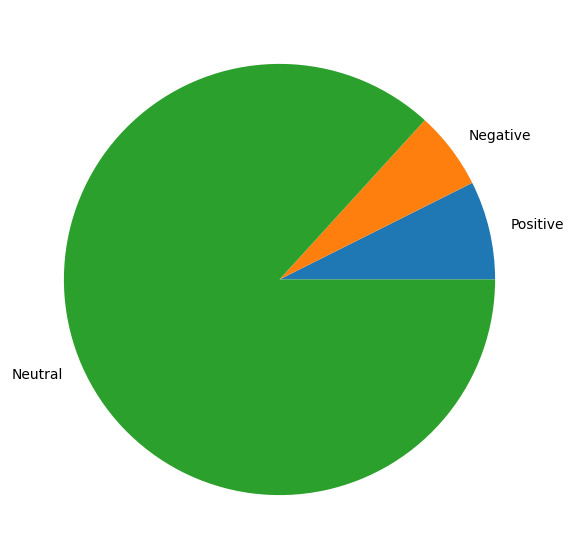

In [42]:
from matplotlib import pyplot as plt
plt.figure(figsize =(10, 7))
plt.pie([positive,negative,neutral], labels = ['Positive','Negative','Neutral'])

In [43]:
from sklearn.feature_extraction.text import CountVectorizer


In [44]:
def top_n_ngram(corpus,n = None,ngram = 1):
    vec = CountVectorizer(stop_words = 'english',ngram_range=(ngram,ngram)).fit(corpus)
    bag_of_words = vec.transform(corpus) #Have the count of  all the words for each review
    sum_words = bag_of_words.sum(axis =0) #Calculates the count of all the word in the whole review
    words_freq = [(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq,key = lambda x:x[1],reverse = True)
    return words_freq[:n]


Visualizing Top 20 Unigrams

<Axes: title={'center': 'Top 20 unigrams in review after removing stop words'}, xlabel='ReviewText'>

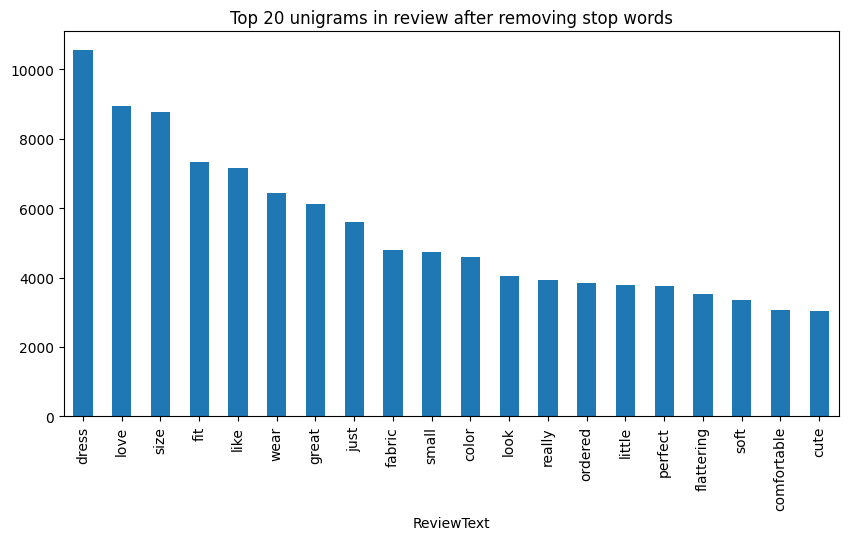

In [45]:
common_words = top_n_ngram(data['Review Text'], 20,1)
df = pd.DataFrame(common_words, columns = ['ReviewText' , 'count'])
plt.figure(figsize =(10,5))
df.groupby('ReviewText').sum()['count'].sort_values(ascending=False).plot(
kind='bar', title='Top 20 unigrams in review after removing stop words')

Visualizing Top 20 Bigrams

<Axes: title={'center': 'Top 20 bigrams in review after removing stop words'}, xlabel='ReviewText'>

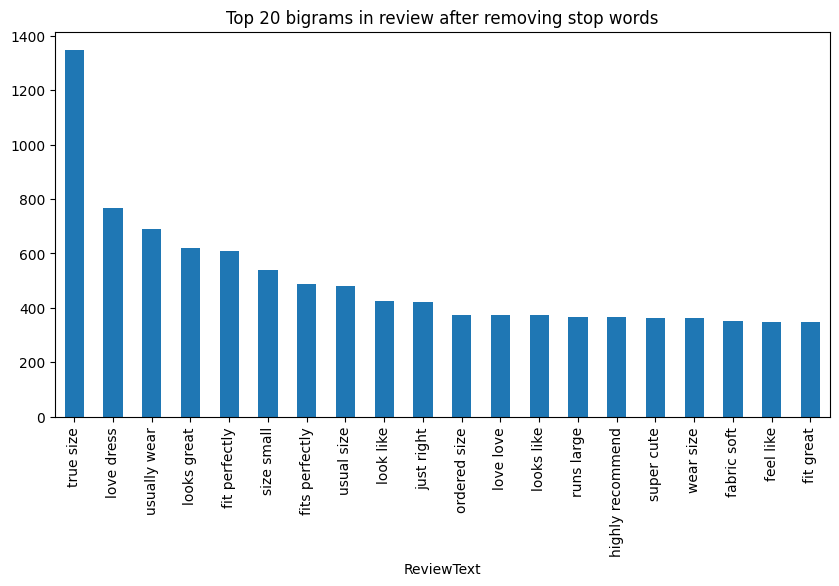

In [46]:
common_words = top_n_ngram(data['Review Text'], 20,2)
df = pd.DataFrame(common_words, columns = ['ReviewText' , 'count'])
plt.figure(figsize =(10,5))
df.groupby('ReviewText').sum()['count'].sort_values(ascending=False).plot(
kind='bar', title='Top 20 bigrams in review after removing stop words')

Visualizing Top 20 Trigrams¶

<Axes: title={'center': 'Top 20 trigrams in review after removing stop words'}, xlabel='ReviewText'>

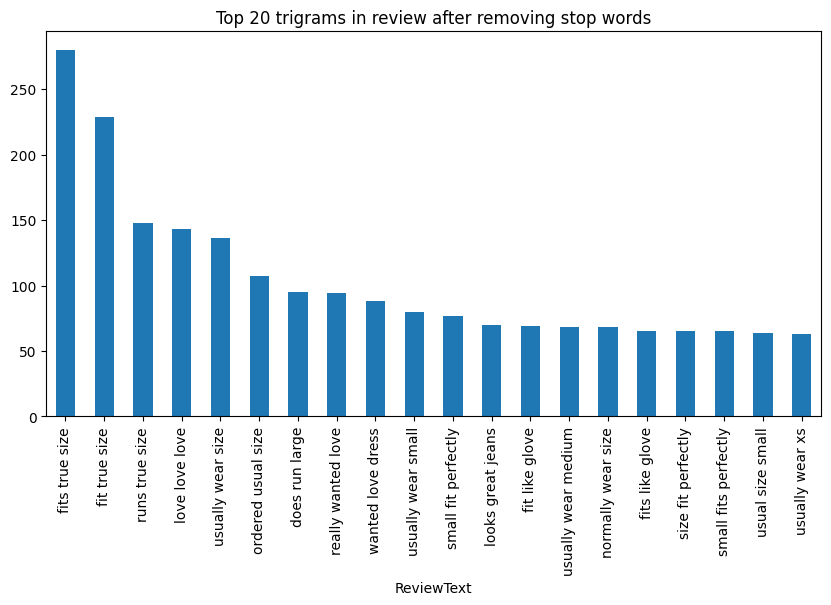

In [47]:
common_words = top_n_ngram(data['Review Text'], 20,3)
df = pd.DataFrame(common_words, columns = ['ReviewText' , 'count'])
plt.figure(figsize =(10,5))
df.groupby('ReviewText').sum()['count'].sort_values(ascending=False).plot(
kind='bar', title='Top 20 trigrams in review after removing stop words')


Visualizing Top 20 Part-of-Speech

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


<Axes: title={'center': 'Top 20 Part-of-speech taggings'}, xlabel='pos'>

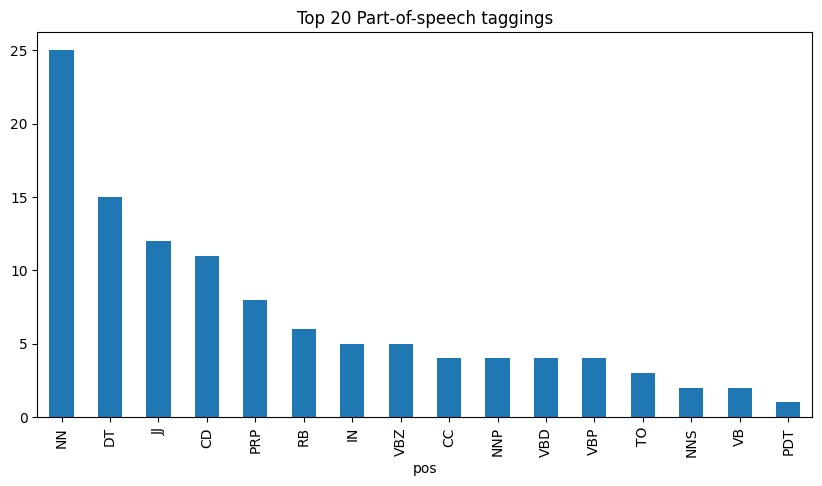

In [50]:
!python -m textblob.download_corpora
blob= TextBlob(str(data['Review Text']))
pos = pd.DataFrame(blob.tags,columns =['word','pos'])
pos1 = pos.pos.value_counts()[:20]
plt.figure(figsize = (10,5))
pos1.plot(kind='bar',title ='Top 20 Part-of-speech taggings')

In [51]:
y = data['Recommended IND']


In [52]:
X = data.drop(columns = 'Recommended IND')


Correlation HeatMap

<Axes: >

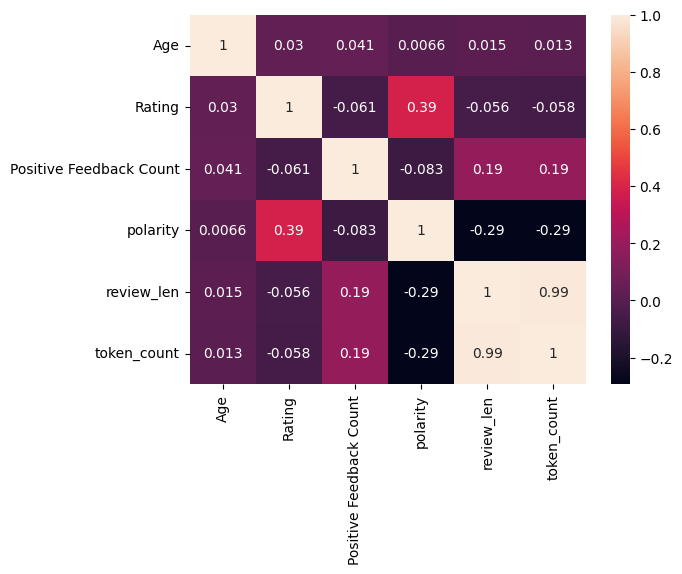

In [54]:
import seaborn as sns
sns.heatmap(X.select_dtypes(include=['number']).corr(),annot =True)

Handling Multi-Colinearity

In [56]:
set1 =set()
cor = X.select_dtypes(include=['number']).corr()
for i in cor.columns:
    for j in cor.columns:
        if cor[i][j]>0.8 and i!=j:
            set1.add(i)
print(set1)

{'token_count', 'review_len'}


In [57]:
X = X.drop(labels = ['token_count'],axis = 1)

In [59]:
X.select_dtypes(include=['number']).corr()

,Age,Rating,Positive Feedback Count,polarity,review_len
Age,1.000000,0.029962,0.040850,0.006649,0.014931
Rating,0.029962,1.000000,-0.060984,0.386303,-0.056199
Positive Feedback Count,0.040850,-0.060984,1.000000,-0.083379,0.191195
polarity,0.006649,0.386303,-0.083379,1.000000,-0.290693
review_len,0.014931,-0.056199,0.191195,-0.290693,1.000000


In [60]:
class1 =[]
for i in X.polarity:
    if float(i)>=0.0:
        class1.append(1)
    elif float(i)<0.0:
        class1.append(0)
X['sentiment'] = class1

Statistical Description of Data

In [61]:
X.groupby(X['sentiment']).describe().T

sentiment                                 0             1
Age                     count  1.315000e+03  21326.000000
                        mean   4.308213e+01     43.292601
                        std    1.199712e+01     12.347201
                        min    2.000000e+01     18.000000
                        25%    3.400000e+01     34.000000
                        50%    4.100000e+01     41.000000
                        75%    5.100000e+01     52.000000
                        max    9.400000e+01     99.000000
Rating                  count  1.315000e+03  21326.000000
                        mean   2.910266e+00      4.262074
                        std    1.346796e+00      1.050613
                        min    1.000000e+00      1.000000
                        25%    2.000000e+00      4.000000
                        50%    3.000000e+00      5.000000
                        75%    4.000000e+00      5.000000
                        max    5.000000e+00      5.000000
Positive Feedback Count count  1.315000e+03  21326.000000
                        mean   3.191635e+00      2.595986
                        std    6.825823e+00      5.714255
                        min    0.000000e+00      0.000000
                        25%    0.000000e+00      0.000000
                        50%    1.000000e+00      1.000000
                        75%    3.000000e+00      3.000000
                        max    1.080000e+02    122.000000
polarity                count  1.315000e+03  21326.000000
                        mean  -9.474088e-02      0.271070
                        std    1.043440e-01      0.157153
                        min   -9.750000e-01      0.000000
                        25%   -1.250000e-01      0.158836
                        50%   -6.280864e-02      0.250000
                        75%   -2.726484e-02      0.358333
                        max   -1.734723e-18      1.000000
review_len              count  1.315000e+03  21326.000000
                        mean   2.965795e+02    309.434540
                        std    1.407817e+02    144.102467
                        min    1.100000e+01      9.000000
                        25%    1.800000e+02    187.000000
                        50%    2.830000e+02    303.000000
                        75%    4.250000e+02    460.000000
                        max    5.060000e+02    508.000000

Model Building

In [75]:
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [76]:
corpus =[]
print('Corpus list reset.')

Corpus list reset.


In [77]:
X.index = np.arange(len(X))


In [78]:
for i in range(len(X)):
    review = re.sub('[^a-zA-z]',' ',X['Review Text'][i])
    review = review.lower()
    review = review.split()
    ps = PorterStemmer()
    review =[ps.stem(i) for i in review if not i in set(stopwords.words('english'))]
    review =' '.join(review)
    corpus.append(review)

In [84]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features = 5000)
X_cv = cv.fit_transform(corpus).toarray()

In [85]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_cv,y,test_size = 0.25,random_state = 0)

In [86]:
from sklearn.naive_bayes import BernoulliNB
classifier = BernoulliNB()
classifier.fit(X_train,y_train)

BernoulliNB()

In [87]:
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc}")

Accuracy Score: 0.8736972266384031


In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer as TV
tv  = TV(ngram_range =(1,1),max_features = 3000)
X_tv = tv.fit_transform(corpus).toarray()

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X_tv, y, test_size = 0.20, random_state = 0)
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

MultinomialNB()

In [90]:
y_pred = classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [91]:
acc

0.8372709207330536

Deep Learning Mode

In [92]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [93]:
tokenizer = Tokenizer(num_words = 3000)
tokenizer.fit_on_texts(corpus)

In [94]:
sequences = tokenizer.texts_to_sequences(corpus)
padded = pad_sequences(sequences, padding='post')

In [95]:
word_index = tokenizer.word_index
count = 0
for i,j in word_index.items():
    if count == 11:
        break
    print(i,j)
    count = count+1

dress 1
fit 2
love 3
size 4
look 5
top 6
wear 7
like 8
color 9
great 10
would 11


In [96]:
embedding_dim = 64
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(3000, embedding_dim),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [97]:
num_epochs = 10

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [98]:
model.fit(padded,y,epochs= num_epochs)


Epoch 1/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8188 - loss: 0.4542
Epoch 2/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8702 - loss: 0.2936
Epoch 3/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8924 - loss: 0.2519
Epoch 4/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9001 - loss: 0.2376
Epoch 5/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9050 - loss: 0.2294
Epoch 6/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9085 - loss: 0.2225
Epoch 7/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9095 - loss: 0.2162
Epoch 8/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9126 - loss: 0.2109
Epoch 9/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9148 - loss: 0.2076
Epoch 10/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9171 - loss: 0.2014


In [99]:
sample_string = "I Will tell my friends for sure"
sample = tokenizer.texts_to_sequences(sample_string)
padded_sample = pad_sequences(sample, padding='post')

In [100]:
padded_sample.T


array([[   0,    0,  557,    0,  280,  280,    0,    0, 1115,  280,  280,
           0,    0,    0,    0,  932, 1309,    0, 1115, 1377,    0,    0,
           0,  932,    0, 1309,    0,    0, 1792, 1309, 1115]],
      dtype=int32)

In [101]:
model.predict(padded_sample.T)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


array([[0.9981571]], dtype=float32)

In [102]:
data = pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv', index_col=[0])
display(data.head())

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
